In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import sys; sys.path.append("../utils")
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')
import copy

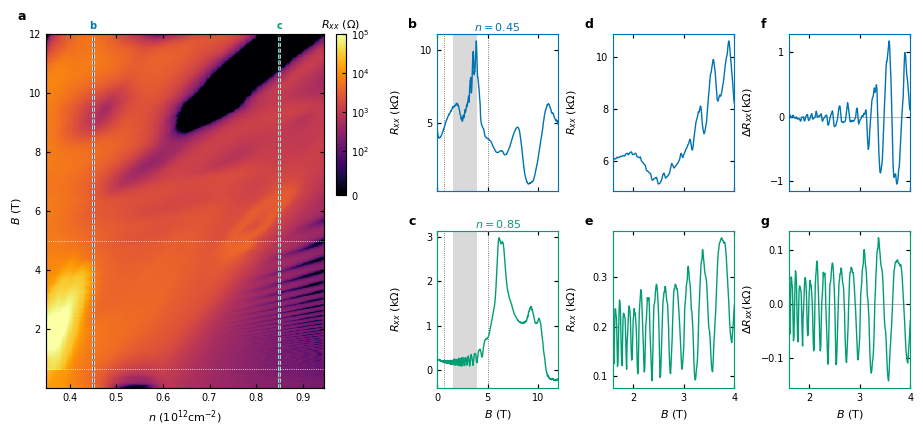

In [ ]:

zf_targets = [0.45, 0.85]
zf_colors = ['#0173B2', '#029E73', '#D55E00', '#CC78BC', '#DE8F05']
ZF_DN = 0.012          # density offset applied to file 1637 to match 1840
ZF_BMIN = 0.02         # drop 1637's glitched first two points
zf_seams = (0.65, 5.0)  # 1637 | 1840 | 1959
zf_zoom = (1.6, 4.0)    # window shown in the right-hand column
dzf_zoom_ypad = 0.05     # y margin, as a fraction of the window's Rxx range
# Filter parameters for last column
ZF_BG = {'cutoff': 8*0.228, 'order': 4}

analyzer_zeroB = Lf_analysis(1637, contact=2)
analyzer_lowB = Lf_analysis(1840, contact=2)
analyzer_highB = Lf_analysis(1959, contact=2)


def zf_segment(analyzer, n_target, blims, dn=0.0):
    """Raw Rxx(B) at exactly n_target + dn over blims. No background subtraction."""
    B = np.asarray(analyzer.B_raw, float)
    Rxx = np.asarray(analyzer.Rxx_raw, float)
    order = np.argsort(B)
    B, Rxx = B[order], Rxx[order]
    keep = np.append(np.diff(B) > 0, True)     # drop repeated / flat-B points
    B, Rxx = B[keep], Rxx[keep]
    # Interpolate in density; the files' grids differ (201 / 231 / 201 columns).
    dens_order = np.argsort(analyzer.density)
    dens = np.asarray(analyzer.density, float)[dens_order]
    cut = np.array([np.interp(n_target + dn, dens, row[dens_order]) for row in Rxx])
    m = (blims[0] <= B) & (B <= blims[1]) & np.isfinite(cut)
    return B[m], cut[m]


def zf_cut(n_target):
    """Continuous raw linecut, 0.02-12 T, stitched at zf_seams."""
    segs = [
        zf_segment(analyzer_zeroB, n_target, (ZF_BMIN, zf_seams[0]), dn=ZF_DN),
        zf_segment(analyzer_lowB, n_target, (zf_seams[0], zf_seams[1])),
        zf_segment(analyzer_highB, n_target, (zf_seams[1] + 1e-9, np.inf)),
    ]
    return (np.concatenate([s[0] for s in segs]),
            np.concatenate([s[1] for s in segs]))


def zf_sorted(analyzer):
    """Raw Rxx with B ascending and de-duplicated, columns in ascending density."""
    B = np.asarray(analyzer.B_raw, float)
    Rxx = np.asarray(analyzer.Rxx_raw, float)
    order = np.argsort(B)
    B, Rxx = B[order], Rxx[order]
    keep = np.append(np.diff(B) > 0, True)     # drop repeated / flat-B points
    B, Rxx = B[keep], Rxx[keep]
    dens_order = np.argsort(np.asarray(analyzer.density, float))
    return B, Rxx[:, dens_order], np.asarray(analyzer.density, float)[dens_order]


zf_dens = zf_sorted(analyzer_lowB)[2]      # common density axis for the fan


def zf_block(analyzer, blims, dn=0.0):
    """One file's rows over [blims[0], blims[1]), resampled onto zf_dens + dn."""
    B, Rxx, dens = zf_sorted(analyzer)
    m = (blims[0] <= B) & (B < blims[1])
    return B[m], np.array([np.interp(zf_dens + dn, dens, row) for row in Rxx[m]])


def zf_map():
    """Stitched raw Rxx(n, B) over 0.02-12 T. Returns (density, B, Rxx)."""
    blocks = [
        zf_block(analyzer_zeroB, (ZF_BMIN, zf_seams[0]), dn=ZF_DN),
        zf_block(analyzer_lowB, zf_seams),
        zf_block(analyzer_highB, (zf_seams[1], np.inf)),
    ]
    return (zf_dens,
            np.concatenate([b[0] for b in blocks]),
            np.concatenate([b[1] for b in blocks], axis=0))


fig = plt.figure(figsize=(9.5, 4.6))
# Nested grids: wspace is uniform within a grid, so the outer one pays only for
# the colorbar, the inner only for the linecut gutters. Resize via width_ratios.
gs = GridSpec(1, 2, width_ratios=[1, 1.7], wspace=0.3, left=0.08, right=0.99)
zf_nrows = len(zf_targets)
gs_cuts = GridSpecFromSubplotSpec(zf_nrows, 3, subplot_spec=gs[1], hspace=0.25,
                                  wspace=0.45)
ax_fan = plt.subplot(gs[0])                                         # a: fan
axes_cut = [plt.subplot(gs_cuts[i, 0]) for i in range(zf_nrows)]    # full field range
axes_zoom = [plt.subplot(gs_cuts[i, 1]) for i in range(zf_nrows)]   # zoomed on zf_zoom
axes_sub = [plt.subplot(gs_cuts[i, 2]) for i in range(zf_nrows)]    # zoom, bg subtracted

letters = list(map(chr, range(97, 97 + 26)))
label_spacer = 0.03

#### a: Landau fan ####
dens, B, Rxx_map = zf_map()
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1e5)
plot = ax_fan.pcolormesh(dens, B, Rxx_map, norm=norm, cmap='inferno',
                         rasterized=True, lw=0)
ax_fan.set_xlabel(r'$n$ $\left(10^{12} \mathrm{cm}^{-2}\right)$')
ax_fan.set_ylabel(r'$B$ (T)')
ax_fan.set_xlim(dens.min(), dens.max())
ax_fan.set_ylim(B.min(), B.max())
for s in zf_seams:
    ax_fan.axhline(s, color='w', ls=':', lw=0.6)     # where the files join

# Mark where each linecut was taken
for i, n in enumerate(zf_targets):
    ax_fan.axvline(n, color=zf_colors[i], ls='--', lw=0.8,
                   path_effects=[pe.Stroke(linewidth=1.8, foreground='w'), pe.Normal()])
    ax_fan.annotate(letters[i + 1], (n, B.max()), xytext=(0, 2),
                    textcoords='offset points', color=zf_colors[i],
                    fontweight='bold', ha='center', va='bottom', fontsize=7)

pos = ax_fan.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, letters[0], fontweight='bold')
cb_height = 0.35
cax = fig.add_axes([pos.x1 + 0.012, pos.y1 - cb_height, 0.011, cb_height])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1e2, 1e3, 1e4, 1e5], orientation='vertical')
# Above the bar, not beside it: no room here before the first linecut's ylabel.
cb.ax.set_title(r'$R_{xx}$ ($\Omega$)', pad=4)

#### Linecuts ####
for i in range(zf_nrows):
    n = zf_targets[i]
    color = zf_colors[i]
    B_cut, Rxx = zf_cut(n)

    # Print the joins so the stitch stays checkable.
    # msg = [f'n = {n:.2f}:']
    # for s in zf_seams:
    #     j = np.searchsorted(B_cut, s)
    #     msg.append(f'seam at {s:g} T = {100*(Rxx[j]-Rxx[j-1])/Rxx[j-1]:+.1f}%')
    # msg.append(f'Rxx({B_cut[0]:.2f} T) = {Rxx[0]:.0f} Ohm')
    # print('  '.join(msg))

    ax = axes_cut[i]
    ax.plot(B_cut, Rxx*1e-3, lw=1, color=color)
    ax.axvspan(*zf_zoom, color='0.85', zorder=0, lw=0)   
    for s in zf_seams:
        ax.axvline(s, color='0.35', ls=':', lw=0.6, zorder=1)
    ax.set_xlim(0, B_cut.max())
    ax.set_title(rf'$n = {n:.2f}$', color=color, pad=2)

    ax = axes_zoom[i]
    zoom_mask = (zf_zoom[0] <= B_cut) & (B_cut <= zf_zoom[1])
    ax.plot(B_cut[zoom_mask], Rxx[zoom_mask]*1e-3, lw=1, color=color)
    ax.axvline(zf_seams[1], color='0.35', ls=':', lw=0.6, zorder=1)
    ax.set_xlim(*zf_zoom)
    yscale_lo, yscale_hi = zf_zoom_yscale[i]
    y = Rxx[(yscale_lo <= B_cut) & (B_cut <= yscale_hi)]*1e-3
    pad = zf_zoom_ypad*np.ptp(y)
    ax.set_ylim(y.min() - pad, y.max() + pad)

    # Resample: need a uniform grid
    ax = axes_sub[i]
    B_win = np.linspace(*zf_zoom, zoom_mask.sum())
    dRxx, bg = detrend_butterworth(B_win, np.interp(B_win, B_cut, Rxx), **ZF_BG)
    ax.plot(B_win, dRxx*1e-3, lw=1, color=color)
    ax.axhline(0, color='0.6', lw=0.5, zorder=0)
    ax.axvline(zf_seams[1], color='0.35', ls=':', lw=0.6, zorder=1)
    ax.set_xlim(*zf_zoom)
    ylabels = [r'$R_{xx}$ (k$\Omega$)', r'$R_{xx}$ (k$\Omega$)',
               r'$\Delta R_{xx} $(k$\Omega$)']
    for j, ax in enumerate((axes_cut[i], axes_zoom[i], axes_sub[i])):
        ax.set_ylabel(ylabels[j])
        ax.locator_params(axis='y', nbins=4, steps=[1, 2, 5, 10])
        # Pin the label: tick-label widths differ per panel, margins should not.
        ax.yaxis.set_label_coords(-0.28, 0.5)
        if i == zf_nrows - 1:
            ax.set_xlabel('$B$ (T)')
        else:
            ax.tick_params(labelbottom=False)   
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
        p = ax.get_position()
        fig.text(p.x0 - label_spacer, p.y1 + 0.012, letters[1 + i + zf_nrows*j],
                 fontweight='bold')

plt.savefig('figures/figS_FFT_nobgsub_highfield_fan.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)